In [ ]:
# ── Data Processing ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Deep Learning ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# ── Image Processing ───────────────────────────────────────────────────────────
import os
from pathlib import Path
import joblib
import time

# ── Machine Learning ───────────────────────────────────────────────────────────
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# ── Settings ───────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
np.random.seed(42)
torch.manual_seed(42)

print("✅ All imports successful")

✅ All imports successful


In [ ]:
SUBSET_SIZE  = 44441
BATCH_SIZE   = 64
N_EVAL       = 200   # queries for evaluation
K_NEIGHBORS  = 6     # top-K for metrics
RANDOM_STATE = 42

# Output directories
os.makedirs('models', exist_ok=True)
os.makedirs('models/features', exist_ok=True)
os.makedirs('models/results', exist_ok=True)

print("✅ Config set")
print(f"   Subset size  : {SUBSET_SIZE:,}")
print(f"   Eval queries : {N_EVAL}")
print(f"   Top-K        : {K_NEIGHBORS}")

✅ Config set
   Subset size  : 44,441
   Eval queries : 200
   Top-K        : 6


In [ ]:
# Download the file from your Google Drive link and save it as dataset.zip
!gdown "1g4kiquREfUUXebAMXmNjxtp81ARoJaxO" -O dataset.zip

# Unzip the downloaded file cleanly into a folder named /content/my_dataset
!unzip -q dataset.zip -d /content/my_dataset

print("✅ Dataset downloaded and extracted successfully!")


Downloading...
From (original): https://drive.google.com/uc?id=1g4kiquREfUUXebAMXmNjxtp81ARoJaxO
From (redirected): https://drive.google.com/uc?id=1g4kiquREfUUXebAMXmNjxtp81ARoJaxO&confirm=t&uuid=994aa530-02f5-4b7b-98b2-e4a010b0760c
To: /content/dataset.zip
100% 298M/298M [00:03<00:00, 89.6MB/s]
✅ Dataset downloaded and extracted successfully!


In [ ]:
import pandas as pd
from pathlib import Path

# This points to where we extracted the ZIP file in Step 1
image_dir = Path('/content/my_dataset')

# Using rglob instead of glob.
# It recursively searches all sub-folders so you don't need the exact path!
image_paths = list(image_dir.rglob('*.jpg'))

fashion_data = []
for img_path in image_paths:
    fashion_data.append({
        'image_id'  : img_path.stem,
        'image_path': str(img_path),
        'filename'  : img_path.name
    })

fashion_df = pd.DataFrame(fashion_data)

# Assuming you have SUBSET_SIZE and RANDOM_STATE defined above this somewhere
fashion_df = fashion_df.sample(SUBSET_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"✅ Total images found : {len(image_paths):,}")
print(f"✅ Sampled            : {len(fashion_df):,}")
fashion_df.head()


✅ Total images found : 44,441
✅ Sampled            : 44,441


,image_id,image_path,filename
0,31229,/content/my_dataset/myntradataset/images/31229...,31229.jpg
1,8086,/content/my_dataset/myntradataset/images/8086.jpg,8086.jpg
2,30324,/content/my_dataset/myntradataset/images/30324...,30324.jpg
3,50189,/content/my_dataset/myntradataset/images/50189...,50189.jpg
4,59282,/content/my_dataset/myntradataset/images/59282...,59282.jpg


In [ ]:
import os
import pandas as pd
from pathlib import Path

# Dynamically find the correct path to styles.csv
base_dir = Path('/content/my_dataset')
styles_path = list(base_dir.rglob('styles.csv'))

if styles_path:
    styles_path = str(styles_path[0]) # Use the actual path we found!
    print(f"Loading styles from: {styles_path}")

    styles_df = pd.read_csv(styles_path, on_bad_lines='skip')
    styles_df['id'] = styles_df['id'].astype(str)
    fashion_df['image_id'] = fashion_df['image_id'].astype(str)

    fashion_df = fashion_df.merge(styles_df, left_on='image_id', right_on='id', how='left')

    print("✅ Labels merged successfully!")
    print(f"\nCategory distribution:")
    print(fashion_df['masterCategory'].value_counts())
    print(f"\nTotal labeled: {fashion_df['masterCategory'].notna().sum():,}")
else:
    print("❌ styles.csv not found")

fashion_df.head()


Loading styles from: /content/my_dataset/myntradataset/styles.csv
✅ Labels merged successfully!

Category distribution:
masterCategory
Apparel           21392
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64

Total labeled: 44,419


,image_id,image_path,filename,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,31229,/content/my_dataset/myntradataset/images/31229...,31229.jpg,31229,Women,Apparel,Bottomwear,Capris,Pink,Summer,2012.0,Casual,Puma Women Pink Capris
1,8086,/content/my_dataset/myntradataset/images/8086.jpg,8086.jpg,8086,Men,Footwear,Sandal,Sandals,Grey,Fall,2011.0,Casual,ADIDAS Men Terra Sports Syn Grey Sandals
2,30324,/content/my_dataset/myntradataset/images/30324...,30324.jpg,30324,Men,Apparel,Topwear,Tshirts,Off White,Summer,2012.0,Casual,Myntra Men Killer Move Off White T-shirt
3,50189,/content/my_dataset/myntradataset/images/50189...,50189.jpg,50189,Women,Accessories,Bags,Handbags,Yellow,Summer,2012.0,Casual,Paridhan Women Yellow Handbag
4,59282,/content/my_dataset/myntradataset/images/59282...,59282.jpg,59282,Unisex,Accessories,Watches,Watches,Black,Winter,2016.0,Casual,Titan Him & Her Black Watches


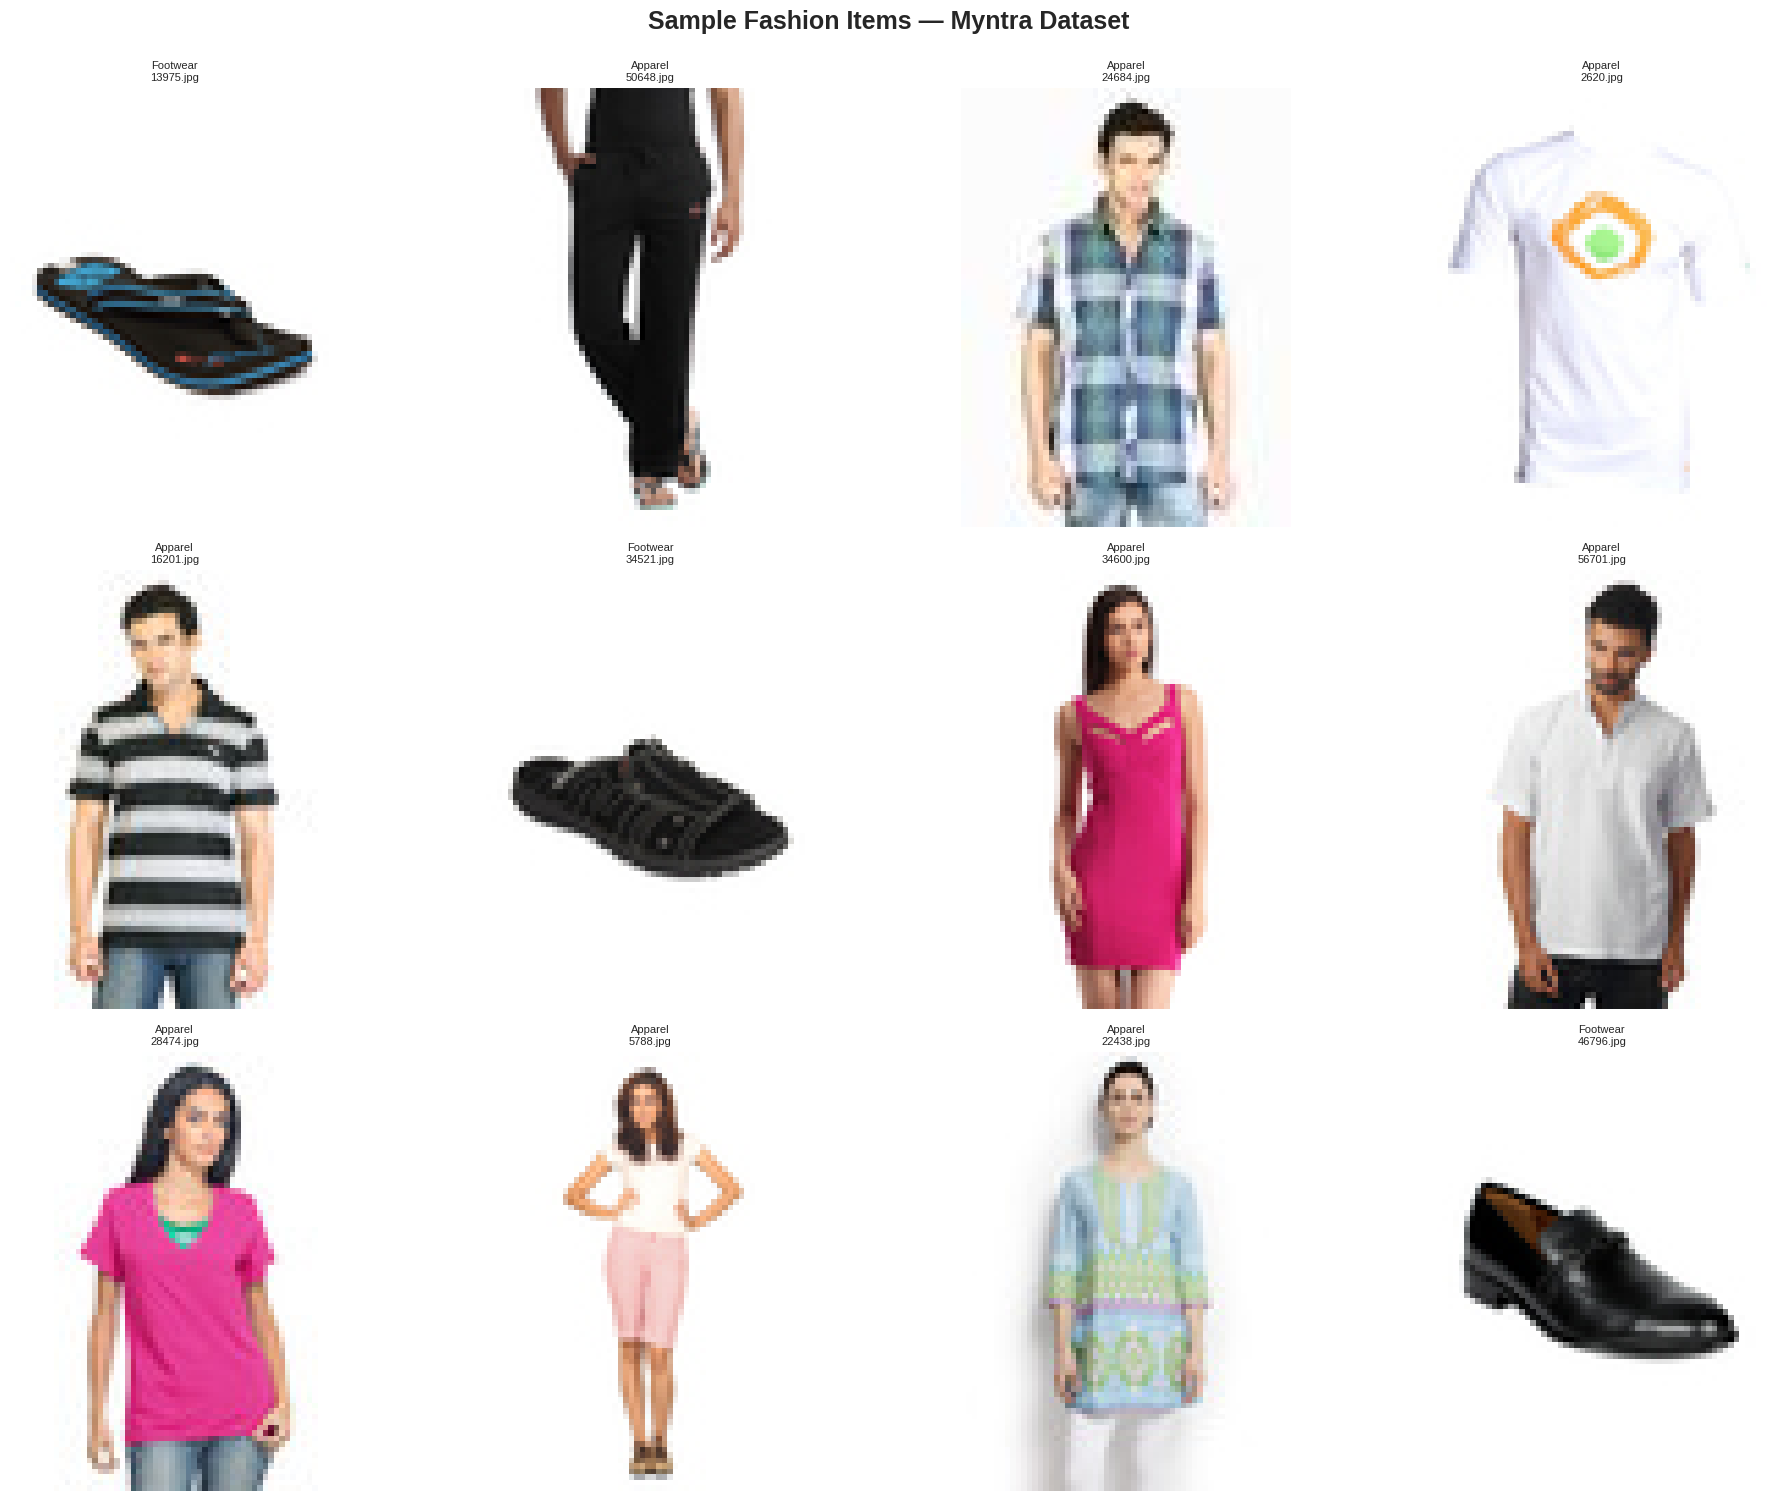

✅ Saved to models/results/sample_images.png


In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Sample Fashion Items — Myntra Dataset',
             fontsize=18, fontweight='bold', y=0.998)

sample_items = fashion_df.sample(12, random_state=RANDOM_STATE)

for ax, (_, item) in zip(axes.flat, sample_items.iterrows()):
    try:
        img   = Image.open(item['image_path'])
        label = item.get('masterCategory', '')
        title = f"{label}\n{item['filename'][:18]}" if pd.notna(label) and label != '' \
                else item['filename'][:20]
        ax.imshow(img)
        ax.set_title(title, fontsize=8, pad=6)
        ax.axis('off')
    except:
        ax.text(0.5, 0.5, 'Error', ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.savefig('models/results/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to models/results/sample_images.png")

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import time
from torchvision import models, transforms
from PIL import Image


class FeatureExtractor:
    """
    Extract features from images using pretrained CNNs
    Supported:
        - resnet18 → 512-D
        - resnet50 → 2048-D
        - vgg16    → 4096-D
    """

    MODEL_CONFIGS = {
        'resnet18': (models.resnet18, models.ResNet18_Weights.IMAGENET1K_V1, 512),
        'resnet50': (models.resnet50, models.ResNet50_Weights.IMAGENET1K_V1, 2048),
        'vgg16':    (models.vgg16,    models.VGG16_Weights.IMAGENET1K_V1,   4096),
    }

    def __init__(self, model_name='resnet50'):
        assert model_name in self.MODEL_CONFIGS, f"Unsupported: {model_name}"

        self.model_name = model_name
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        model_fn, weights, self.feat_dim = self.MODEL_CONFIGS[model_name]
        base = model_fn(weights=weights)

        # ---- Model Setup ----
        if 'resnet' in model_name:
            self.model = nn.Sequential(*list(base.children())[:-1])

        elif 'vgg16' in model_name:
            self.model = nn.Sequential(
                base.features,
                base.avgpool,
                nn.Flatten(),
                base.classifier[0],
                base.classifier[1],
                base.classifier[2],
            )

        self.model = self.model.to(self.device).eval()

        # ---- Image Transform ----
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]
            )
        ])

        print(f"✅ {model_name.upper()} loaded | Feature dim: {self.feat_dim}-D | Device: {self.device}")

    def extract_batch(self, df, batch_size=64):
        """
        Extract features for all images in dataframe
        Returns:
            features_array → numpy array (N, feat_dim)
            valid_df       → dataframe without failed images
        """
        all_features = []
        failed = []
        start = time.time()

        for i in range(0, len(df), batch_size):
            batch_df = df.iloc[i:i+batch_size]
            batch_imgs = []

            for _, row in batch_df.iterrows():
                try:
                    img = Image.open(row['image_path']).convert('RGB')
                    batch_imgs.append(self.transform(img))
                except:
                    failed.append(row['filename'])

            if not batch_imgs:
                continue

            batch_tensor = torch.stack(batch_imgs).to(self.device)

            with torch.no_grad():
                feats = self.model(batch_tensor)

                # ✅ FIXED: universal reshape (no squeeze bug)
                feats = feats.reshape(feats.shape[0], -1)

                feats = feats.cpu().numpy()

            all_features.extend(feats)

            # ---- Progress ----
            if (i + batch_size) % 2000 == 0 or (i + batch_size) >= len(df):
                elapsed = time.time() - start
                progress = min((i + batch_size) / len(df) * 100, 100)
                print(f"{progress:5.1f}% | {len(all_features):,}/{len(df):,} | {elapsed:.0f}s")

        features_array = np.array(all_features, dtype=np.float32)
        valid_df = df[~df['filename'].isin(failed)].reset_index(drop=True)

        print(f"\n✅ Done! Shape: {features_array.shape} | Failed: {len(failed)}")

        return features_array, valid_df

In [ ]:
def evaluate_model(features, metadata, n_eval=200, k=6, model_name='model'):
    """
    Proper stratified evaluation:
    - Samples equally from each masterCategory
    - Avoids class imbalance bias (Apparel = 48% would dominate random sampling)
    - Returns all key metrics for the paper
    """
    print(f"\n{'='*55}")
    print(f"  Evaluating: {model_name.upper()}")
    print(f"{'='*55}")

    # ── L2-normalize features (cosine sim via euclidean on unit vecs) ──────────
    norms = np.linalg.norm(features, axis=1, keepdims=True)
    norms[norms == 0] = 1
    feats_norm = (features / norms).astype(np.float32)

    # ── Build KNN with ball_tree (memory efficient) ────────────────────────────
    knn = NearestNeighbors(
        n_neighbors = min(k + 1, len(feats_norm)),
        metric      = 'euclidean',
        algorithm   = 'ball_tree'
    )
    knn.fit(feats_norm)

    # ── STRATIFIED sampling — equal items per category ─────────────────────────
    labels      = metadata['masterCategory'].fillna('Unknown').values
    categories  = [c for c in pd.Series(labels).unique() if c != 'Unknown']
    per_cat     = max(1, n_eval // len(categories))

    eval_indices = []
    for cat in categories:
        cat_idx = np.where(labels == cat)[0]
        sampled = np.random.choice(cat_idx,
                                   size=min(per_cat, len(cat_idx)),
                                   replace=False)
        eval_indices.extend(sampled.tolist())

    eval_indices = np.array(eval_indices[:n_eval])
    print(f"  Evaluation queries : {len(eval_indices)} (stratified across {len(categories)} categories)")

    # ── Compute metrics ────────────────────────────────────────────────────────
    y_true, y_pred = [], []
    prec_list, rec_list, f1_list = [], [], []
    top1_sims, top5_sims         = [], []
    ils_list                     = []

    for qi in eval_indices:
        q_feat  = feats_norm[qi].reshape(1, -1)
        q_label = labels[qi]

        dists, inds = knn.kneighbors(q_feat, n_neighbors=k+1)
        rec_idx     = inds[0][1:]   # exclude self
        rec_dists   = dists[0][1:]
        rec_labels  = labels[rec_idx]

        # Cosine similarity from unit-vector euclidean distance
        sims = np.clip(1 - (rec_dists ** 2) / 2, 0, 1)

        # Predicted label = majority vote among top-K
        pred_label = pd.Series(rec_labels).mode()[0]
        y_true.append(q_label)
        y_pred.append(pred_label)

        # Precision@K, Recall@K, F1@K
        p = (rec_labels == q_label).mean()
        same_total = max(1, (labels == q_label).sum() - 1)
        r = min(k, (rec_labels == q_label).sum()) / min(k, same_total)
        f = (2 * p * r / (p + r)) if (p + r) > 0 else 0

        prec_list.append(p)
        rec_list.append(r)
        f1_list.append(f)

        # Top-1 and Avg Top-5 similarity
        top1_sims.append(sims[0])
        top5_sims.append(sims[:5].mean())

        # Intra-list similarity (diversity)
        rec_feats = feats_norm[rec_idx]
        ils_mat   = rec_feats @ rec_feats.T
        np.fill_diagonal(ils_mat, 0)
        ils_val   = ils_mat[np.triu_indices(k, k=1)].mean()
        ils_list.append(ils_val)

    # ── Catalog coverage (500 queries) ─────────────────────────────────────────
    cov_n   = min(500, len(feats_norm))
    cov_idx = np.random.choice(len(feats_norm), cov_n, replace=False)
    seen    = set()
    for i in cov_idx:
        _, inds = knn.kneighbors(feats_norm[i].reshape(1,-1), n_neighbors=k+1)
        seen.update(inds[0][1:].tolist())
    coverage = len(seen) / len(feats_norm)

    # ── Summary ────────────────────────────────────────────────────────────────
    results = {
        'model'         : model_name,
        'accuracy'      : round(accuracy_score(y_true, y_pred), 3),
        'precision_k'   : round(np.mean(prec_list), 3),
        'recall_k'      : round(np.mean(rec_list), 3),
        'f1_k'          : round(np.mean(f1_list), 3),
        'top1_sim'      : round(np.mean(top1_sims), 3),
        'top5_sim'      : round(np.mean(top5_sims), 3),
        'ils_diversity' : round(1 - np.mean(ils_list), 3),
        'coverage'      : round(coverage * 100, 1),
        'feat_dim'      : features.shape[1],
        'n_items'       : len(features),
        'knn'           : knn,
        'feats_norm'    : feats_norm,
        'y_true'        : y_true,
        'y_pred'        : y_pred,
    }

    print(f"\n  {'Metric':<22} {'Score':>8}")
    print(f"  {'-'*32}")
    print(f"  {'Accuracy':<22} {results['accuracy']:>8.3f}")
    print(f"  {'Precision@6':<22} {results['precision_k']:>8.3f}")
    print(f"  {'Recall@6':<22} {results['recall_k']:>8.3f}")
    print(f"  {'F1-Score@6':<22} {results['f1_k']:>8.3f}")
    print(f"  {'Top-1 Similarity':<22} {results['top1_sim']:>8.3f}")
    print(f"  {'Avg Top-5 Similarity':<22} {results['top5_sim']:>8.3f}")
    print(f"  {'Diversity (1-ILS)':<22} {results['ils_diversity']:>8.3f}")
    print(f"  {'Catalog Coverage':<22} {results['coverage']:>7.1f}%")
    print(f"{'='*55}")

    return results

In [ ]:
print("="*55)
print("  STEP 1: ResNet18 Feature Extraction (512-D)")
print("="*55)

extractor18       = FeatureExtractor('resnet18')
features18, df18  = extractor18.extract_batch(fashion_df, batch_size=BATCH_SIZE)

# Save
np.save('models/features/features_resnet18.npy', features18)
df18.to_csv('models/features/metadata_resnet18.csv', index=False)
print(f"\n✅ ResNet18 features saved → models/features/features_resnet18.npy")

  STEP 1: ResNet18 Feature Extraction (512-D)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s]


✅ RESNET18 loaded | Feature dim: 512-D | Device: cuda
 18.0% | 8,000/44,441 | 27s
 36.0% | 16,000/44,441 | 54s
 54.0% | 24,000/44,441 | 82s
 72.0% | 32,000/44,441 | 108s
 90.0% | 40,000/44,441 | 135s
100.0% | 44,441/44,441 | 150s

✅ Done! Shape: (44441, 512) | Failed: 0

✅ ResNet18 features saved → models/features/features_resnet18.npy


In [ ]:
print("="*55)
print("  STEP 2: ResNet50 Feature Extraction (2048-D)")
print("="*55)

extractor50       = FeatureExtractor('resnet50')
features50, df50  = extractor50.extract_batch(fashion_df, batch_size=BATCH_SIZE)

# Save
np.save('models/features/features_resnet50.npy', features50)
df50.to_csv('models/features/metadata_resnet50.csv', index=False)
print(f"\n✅ ResNet50 features saved → models/features/features_resnet50.npy")

  STEP 2: ResNet50 Feature Extraction (2048-D)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 145MB/s]


✅ RESNET50 loaded | Feature dim: 2048-D | Device: cuda
 18.0% | 8,000/44,441 | 41s
 36.0% | 16,000/44,441 | 86s
 54.0% | 24,000/44,441 | 129s
 72.0% | 32,000/44,441 | 174s
 90.0% | 40,000/44,441 | 217s
100.0% | 44,441/44,441 | 241s

✅ Done! Shape: (44441, 2048) | Failed: 0

✅ ResNet50 features saved → models/features/features_resnet50.npy


In [ ]:
print("="*55)
print("  STEP 3: VGG16 Feature Extraction (4096-D)")
print("="*55)

extractor16      = FeatureExtractor('vgg16')
features16, df16 = extractor16.extract_batch(fashion_df, batch_size=BATCH_SIZE)

np.save('models/features/features_vgg16.npy', features16)
df16.to_csv('models/features/metadata_vgg16.csv', index=False)
print(f"\n✅ VGG16 features saved | Shape: {features16.shape}")

  STEP 3: VGG16 Feature Extraction (4096-D)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 157MB/s]


✅ VGG16 loaded | Feature dim: 4096-D | Device: cuda
 18.0% | 8,000/44,441 | 59s
 36.0% | 16,000/44,441 | 118s
 54.0% | 24,000/44,441 | 180s
 72.0% | 32,000/44,441 | 242s
 90.0% | 40,000/44,441 | 303s
100.0% | 44,441/44,441 | 336s

✅ Done! Shape: (44441, 4096) | Failed: 0

✅ VGG16 features saved | Shape: (44441, 4096)


In [ ]:
print("\n🔍 Running stratified evaluation on all 3 models...\n")

results18 = evaluate_model(features18, df18, n_eval=N_EVAL, k=K_NEIGHBORS, model_name='ResNet18')
results50 = evaluate_model(features50, df50, n_eval=N_EVAL, k=K_NEIGHBORS, model_name='ResNet50')
results16 = evaluate_model(features16, df16, n_eval=N_EVAL, k=K_NEIGHBORS, model_name='VGG16')

print("\n\n📊 COMPARISON TABLE")
print("="*75)
print(f"{'Metric':<25} {'ResNet18':>10} {'VGG16':>10} {'ResNet50':>10}")
print(f"{'':25} {'(512-D)':>10} {'(4096-D)':>10} {'(2048-D)':>10}")
print("-"*75)

metrics = [
    ('Accuracy',            'accuracy'),
    ('Precision@6',         'precision_k'),
    ('Recall@6',            'recall_k'),
    ('F1-Score@6',          'f1_k'),
    ('Top-1 Similarity',    'top1_sim'),
    ('Avg Top-5 Similarity','top5_sim'),
    ('Diversity (1-ILS)',   'ils_diversity'),
    ('Catalog Coverage (%)', 'coverage'),
    ('Feature Dim',         'feat_dim'),
]

for label, key in metrics:
    v18 = results18[key]
    v50 = results50[key]
    v16 = results16[key]
    best = max([v18, v50, v16])
    # Bold best with arrow
    row = f"{label:<25}"
    for v in [v18, v16, v50]:
        marker = ' ◄' if v == best else '  '
        row   += f" {str(v):>9}{marker}"
    print(row)

print("="*75)
print("◄ = Best performing model")


🔍 Running stratified evaluation on all 3 models...


  Evaluating: RESNET18
  Evaluation queries : 166 (stratified across 7 categories)

  Metric                    Score
  --------------------------------
  Accuracy                  0.759
  Precision@6               0.762
  Recall@6                  0.762
  F1-Score@6                0.762
  Top-1 Similarity          0.924
  Avg Top-5 Similarity      0.906
  Diversity (1-ILS)         0.111
  Catalog Coverage           6.4%

  Evaluating: RESNET50
  Evaluation queries : 166 (stratified across 7 categories)

  Metric                    Score
  --------------------------------
  Accuracy                  0.777
  Precision@6               0.789
  Recall@6                  0.789
  F1-Score@6                0.789
  Top-1 Similarity          0.940
  Avg Top-5 Similarity      0.925
  Diversity (1-ILS)         0.088
  Catalog Coverage           6.4%

  Evaluating: VGG16
  Evaluation queries : 166 (stratified across 7 categories)

  Metric     

In [ ]:
comparison_df = pd.DataFrame([
    {
        'Model'             : r['model'],
        'Feature Dim'       : r['feat_dim'],
        'Accuracy'          : r['accuracy'],
        'Precision@6'       : r['precision_k'],
        'Recall@6'          : r['recall_k'],
        'F1-Score@6'        : r['f1_k'],
        'Top-1 Similarity'  : r['top1_sim'],
        'Avg Top-5 Sim'     : r['top5_sim'],
        'Diversity (1-ILS)' : r['ils_diversity'],
        'Catalog Coverage %': r['coverage'],
    }
    for r in [results18, results16, results50]
])

comparison_df.to_csv('models/results/model_comparison.csv', index=False)
print("✅ Comparison saved to models/results/model_comparison.csv")
print("\n", comparison_df.to_string(index=False))

✅ Comparison saved to models/results/model_comparison.csv

    Model  Feature Dim  Accuracy  Precision@6  Recall@6  F1-Score@6  Top-1 Similarity  Avg Top-5 Sim  Diversity (1-ILS)  Catalog Coverage %
ResNet18          512     0.759        0.762     0.762       0.762             0.924          0.906              0.111                 6.4
   VGG16         4096     0.729        0.762     0.762       0.762             0.878          0.852              0.163                 6.4
ResNet50         2048     0.777        0.789     0.789       0.789             0.940          0.925              0.088                 6.4


Running t-SNE on ResNet50 embeddings...


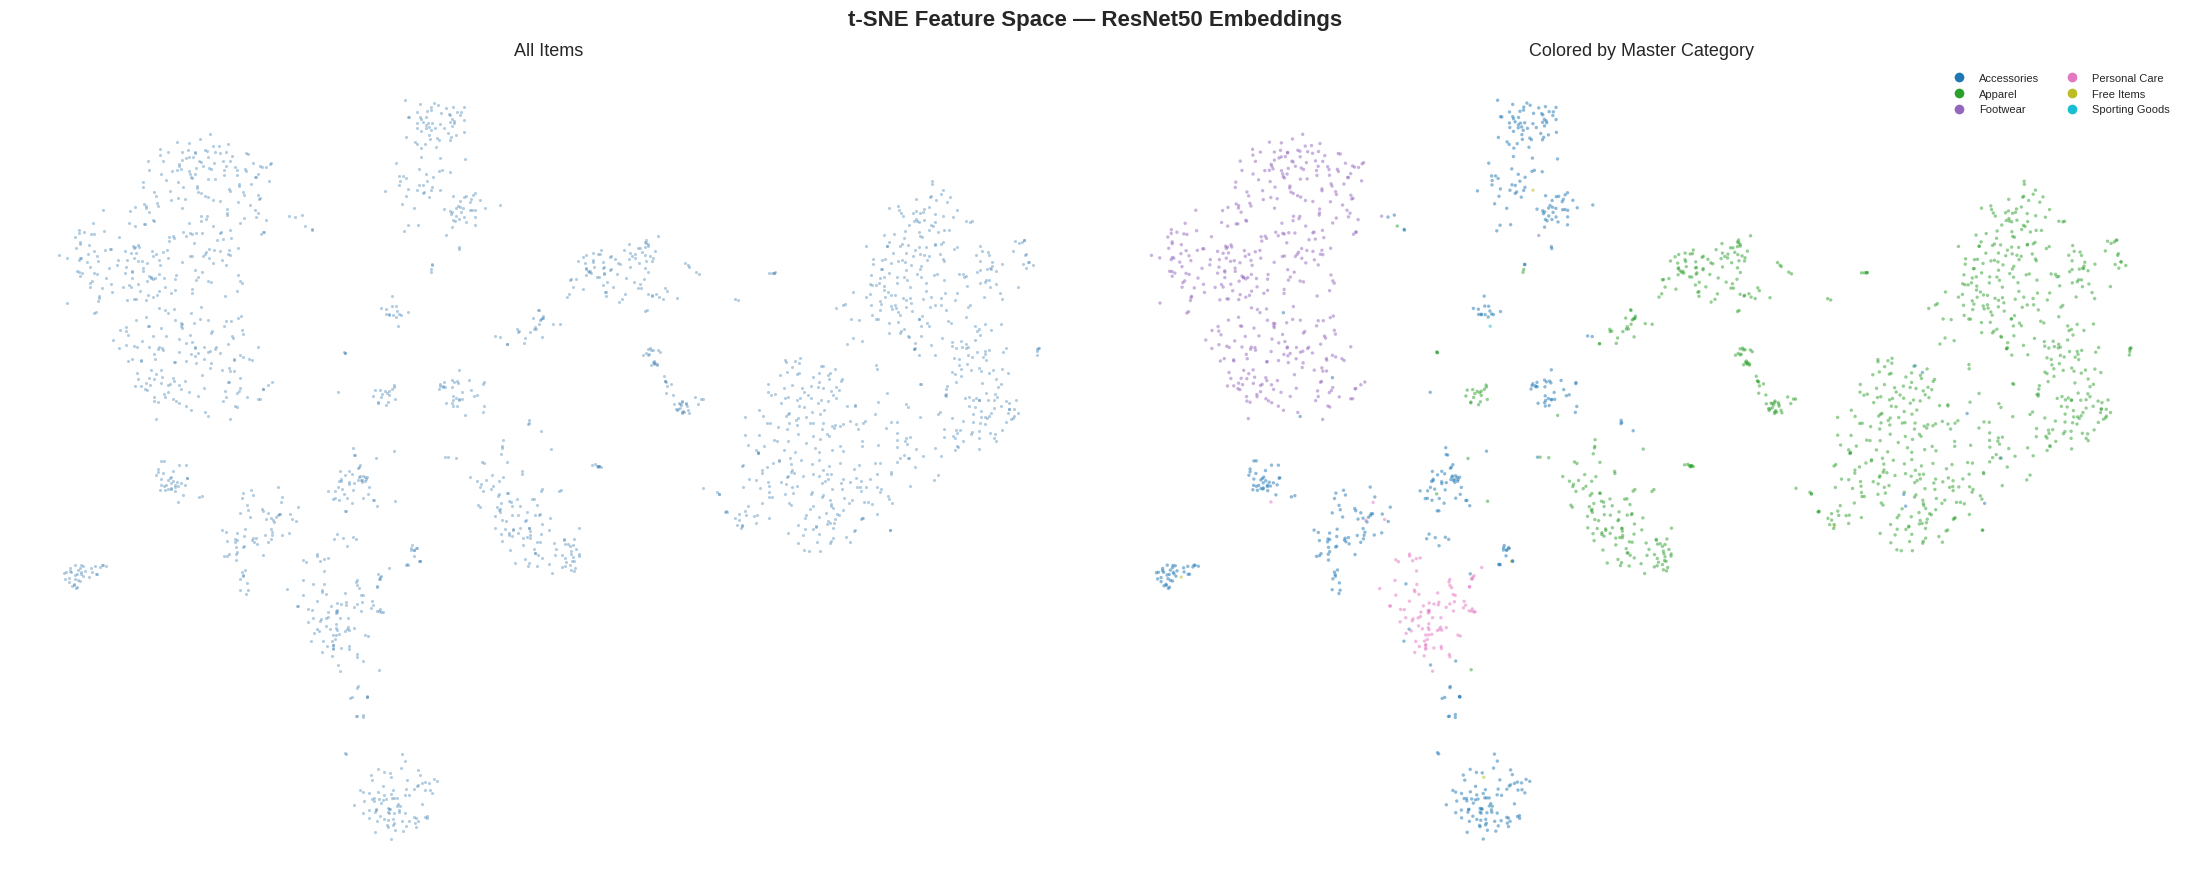

✅ t-SNE saved


In [ ]:
print("Running t-SNE on ResNet50 embeddings...")

TSNE_SAMPLE = 2000
tsne_idx    = np.random.choice(len(features50), TSNE_SAMPLE, replace=False)
pca_pre     = PCA(n_components=50, random_state=42).fit_transform(features50[tsne_idx])
tsne_coords = TSNE(n_components=2, perplexity=40, learning_rate='auto',
                   init='pca', random_state=42).fit_transform(pca_pre)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('t-SNE Feature Space — ResNet50 Embeddings',
             fontsize=16, fontweight='bold')

axes[0].scatter(tsne_coords[:,0], tsne_coords[:,1],
                alpha=0.4, s=5, c='steelblue', linewidths=0)
axes[0].set_title('All Items', fontsize=13)
axes[0].axis('off')

palette     = plt.colormaps['tab10']
cats        = df50.iloc[tsne_idx]['masterCategory'].fillna('Unknown').values
unique_cats = list(pd.Series(cats).unique())
cat_to_idx  = {c:i for i,c in enumerate(unique_cats)}
colors_arr  = [palette(cat_to_idx[c] / max(len(unique_cats)-1, 1)) for c in cats]

axes[1].scatter(tsne_coords[:,0], tsne_coords[:,1],
                c=colors_arr, alpha=0.5, s=6, linewidths=0)
patches = [plt.Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=palette(i/max(len(unique_cats)-1,1)),
                       markersize=8, label=c)
           for i,c in enumerate(unique_cats)]
axes[1].legend(handles=patches, fontsize=8, framealpha=0.8, ncol=2)
axes[1].set_title('Colored by Master Category', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('models/results/tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE saved")

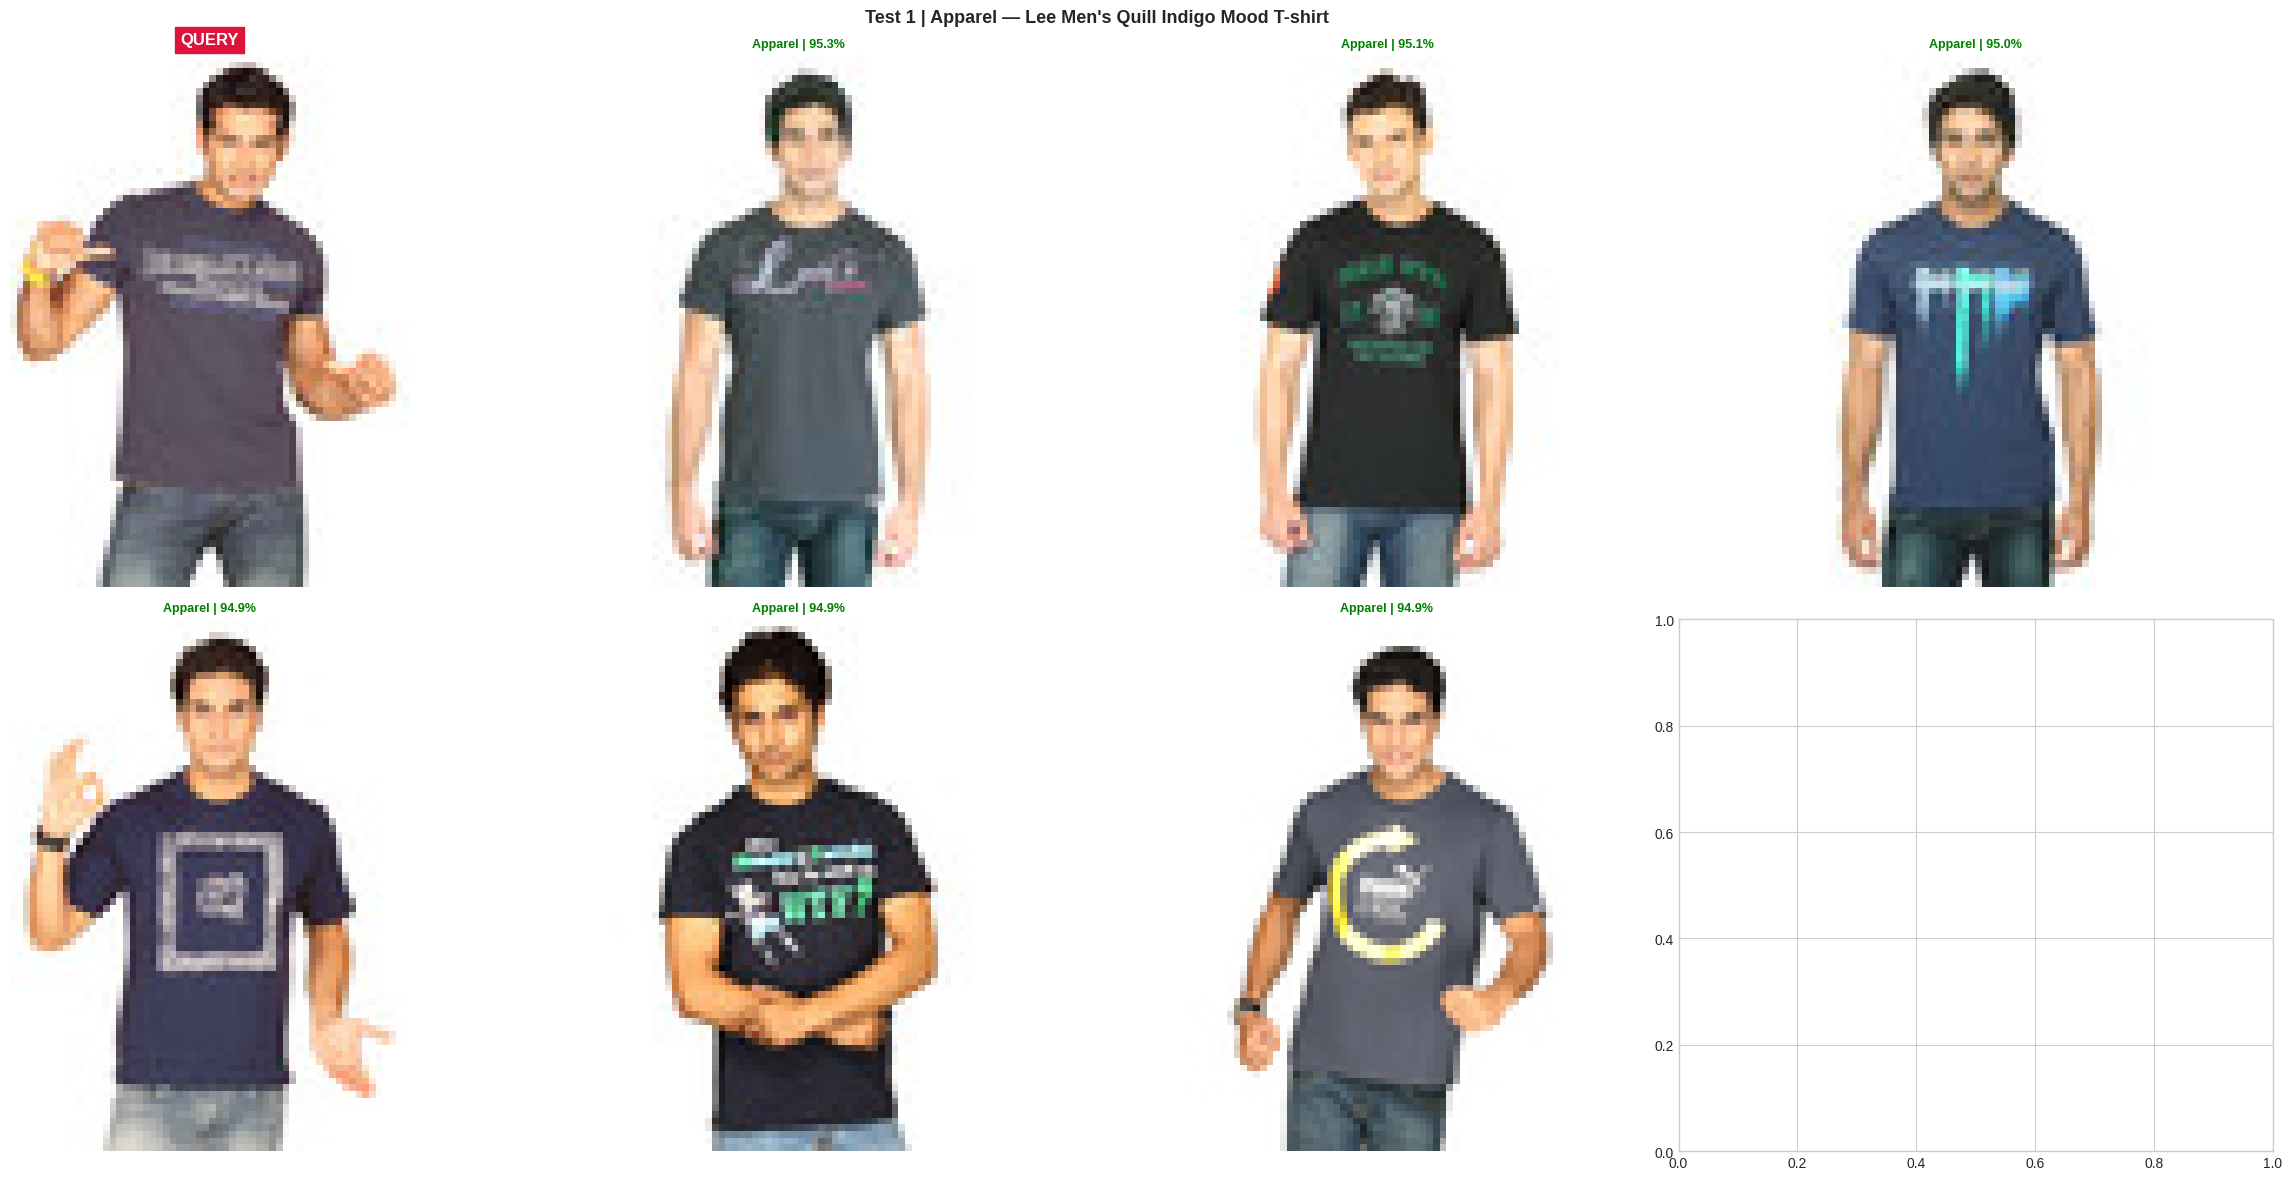

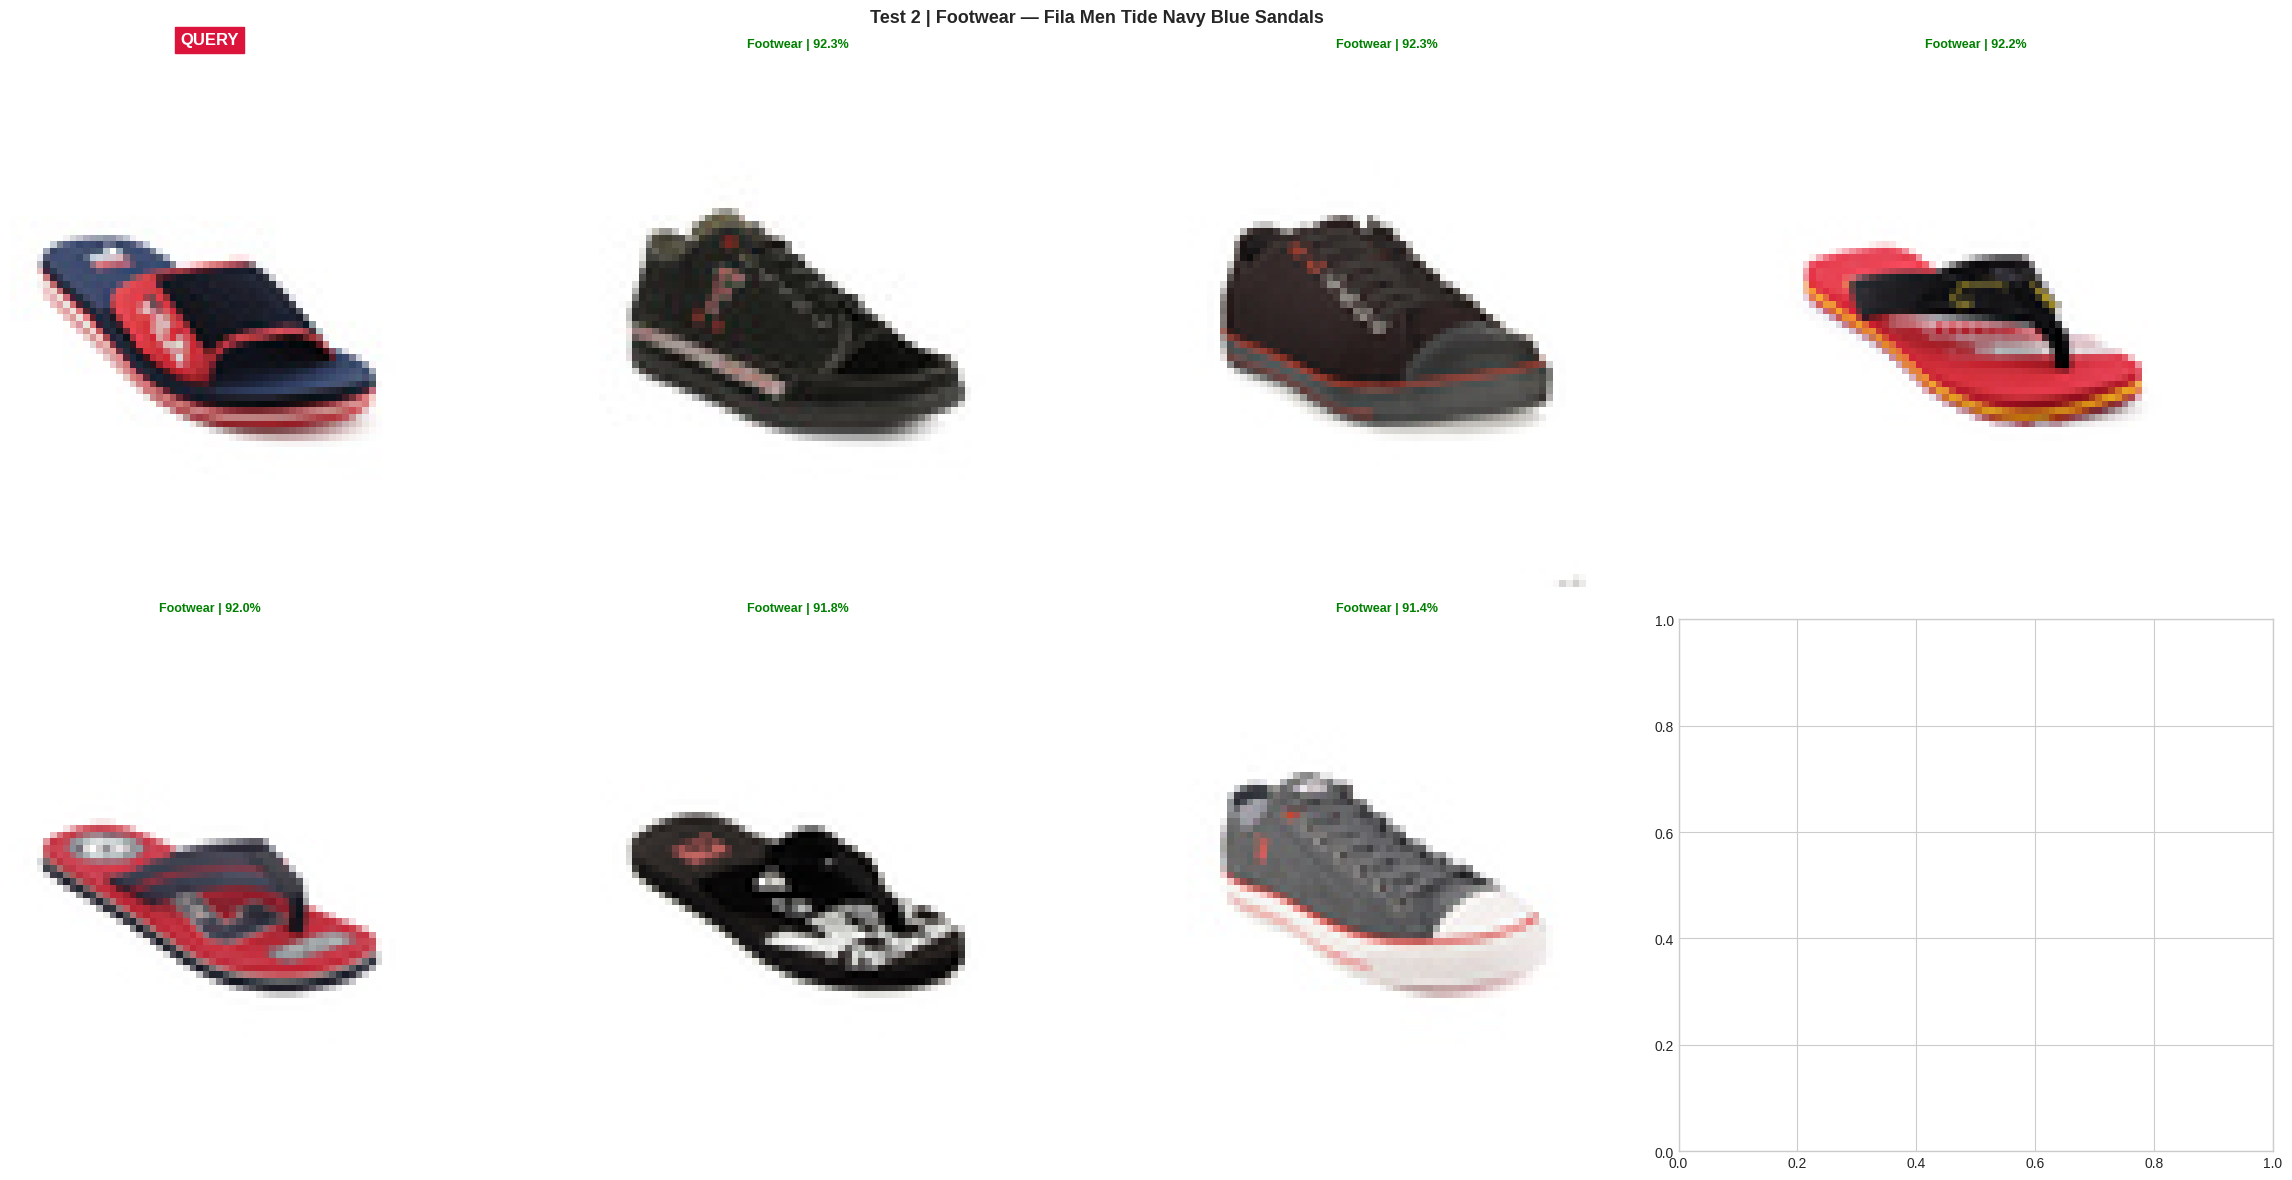

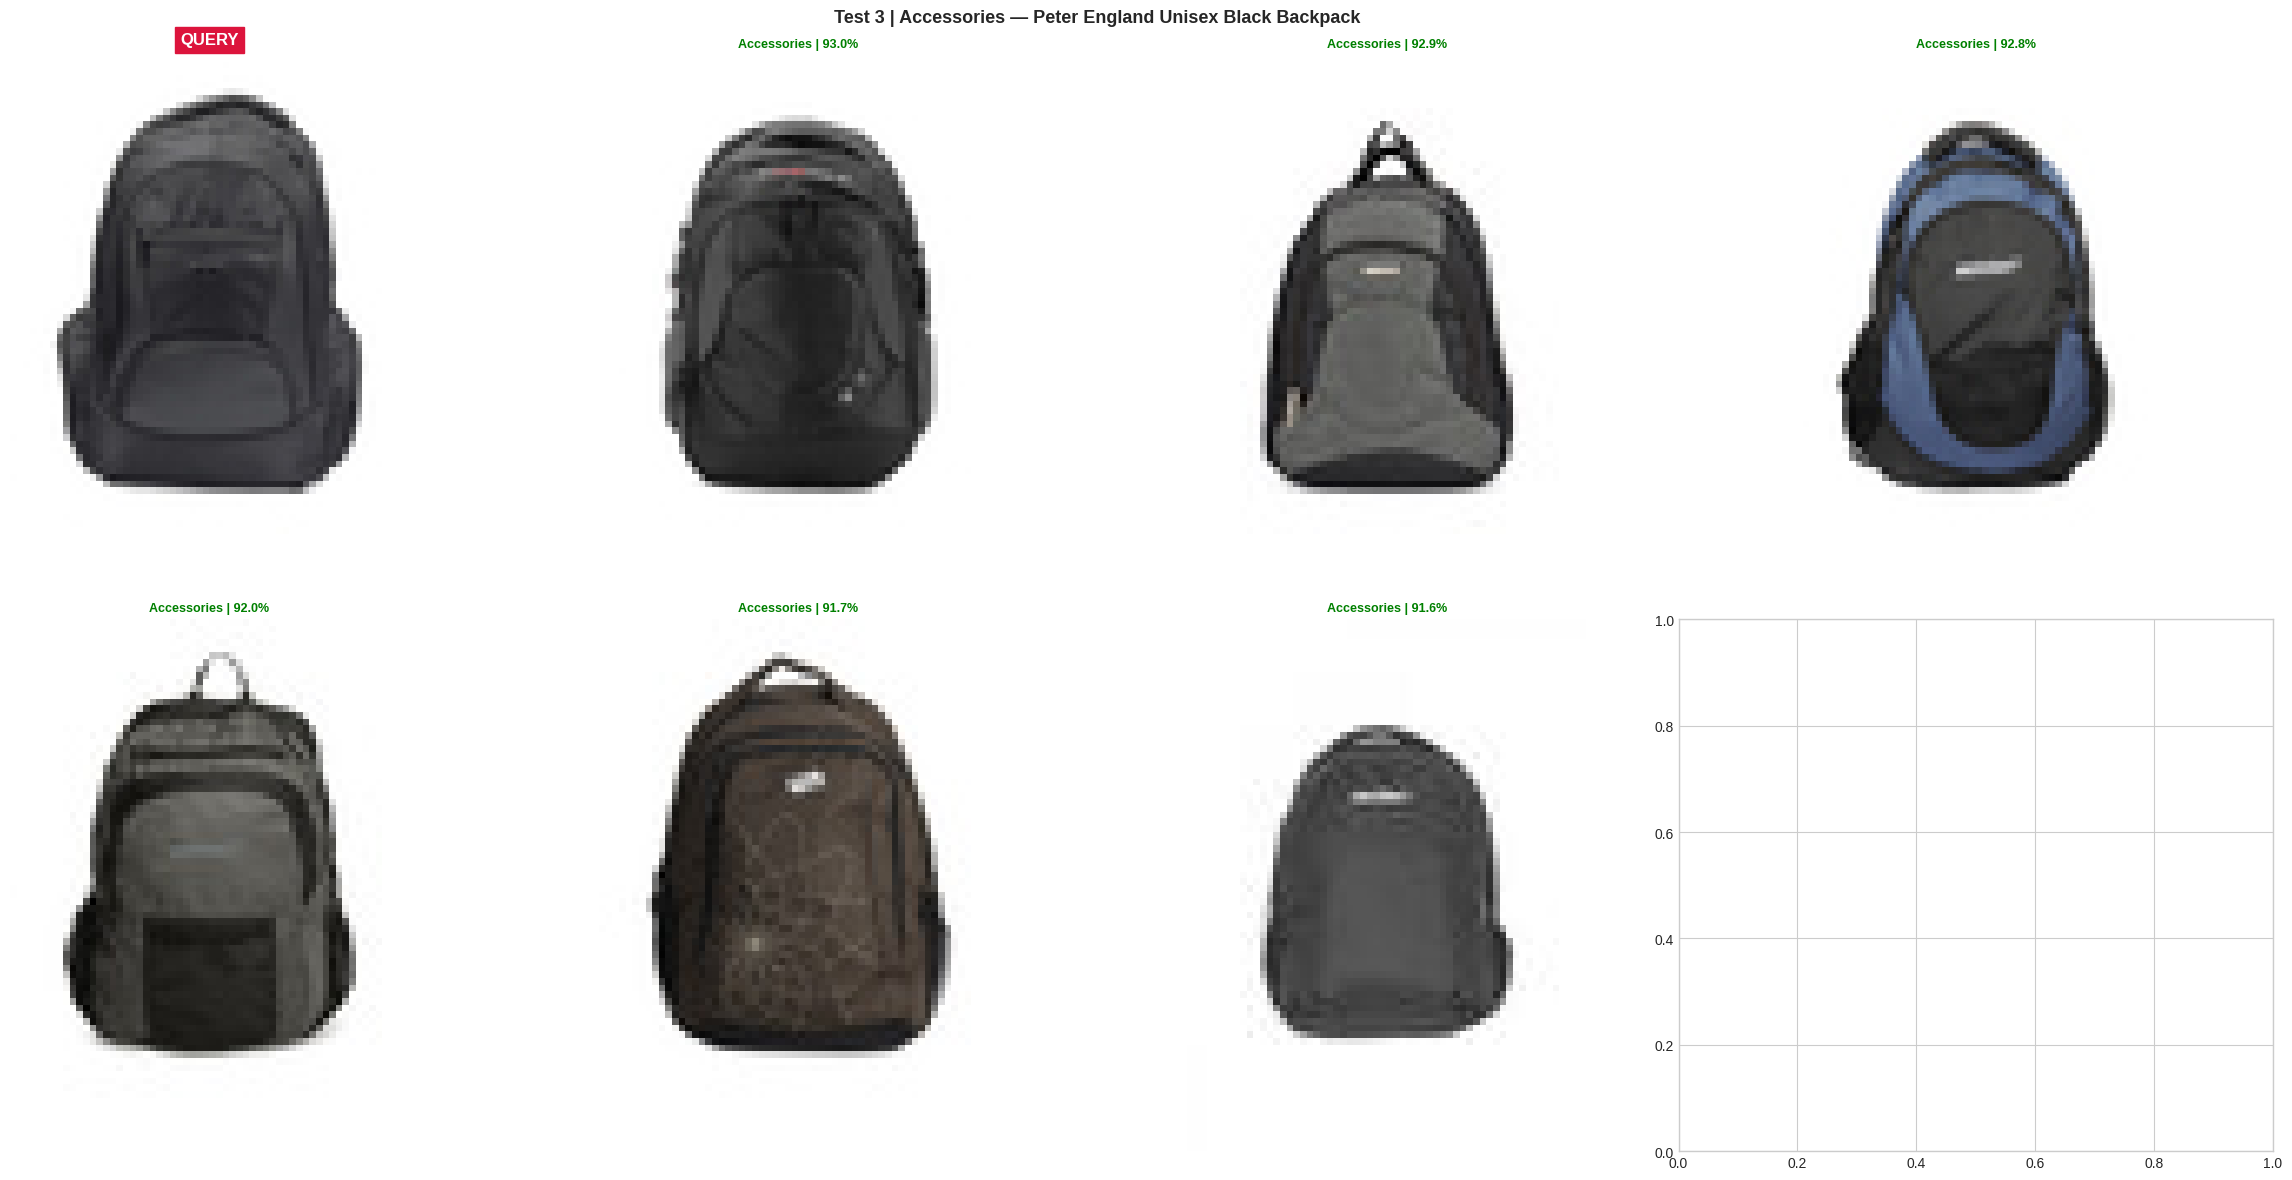

In [ ]:
knn50    = results50['knn']
feats_n  = results50['feats_norm']

for test_num in range(3):
    test_idx   = np.random.randint(0, len(df50))
    query_item = df50.iloc[test_idx]
    q_feat     = feats_n[test_idx].reshape(1, -1)

    dists, inds = knn50.kneighbors(q_feat, n_neighbors=K_NEIGHBORS+1)
    rec_idx     = inds[0][1:]
    sims        = np.clip(1 - (dists[0][1:] ** 2) / 2, 0, 1)
    recs        = df50.iloc[rec_idx].copy()
    recs['sim'] = sims

    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    fig.suptitle(
        f"Test {test_num+1} | {query_item.get('masterCategory','')} — "
        f"{str(query_item.get('productDisplayName',''))[:45]}",
        fontsize=13, fontweight='bold'
    )
    try:
        axes[0,0].imshow(Image.open(query_item['image_path']))
        axes[0,0].set_title('QUERY', fontweight='bold', fontsize=12,
                             color='white', backgroundcolor='crimson', pad=8)
        axes[0,0].axis('off')
    except: axes[0,0].axis('off')

    for ax, (_, rec) in zip(axes.flat[1:], recs.iterrows()):
        try:
            ax.imshow(Image.open(rec['image_path']))
            ax.set_title(f"{rec.get('masterCategory','')} | {rec['sim']:.1%}",
                         fontsize=9, color='green', fontweight='bold')
            ax.axis('off')
        except: ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'models/results/recommendation_test_{test_num+1}.png',
                dpi=120, bbox_inches='tight')
    plt.show()

In [ ]:
# ─── Save all three models as separate .pkl files for the Streamlit app ──────
os.makedirs('models', exist_ok=True)

def save_model_pkl(features, df, results, model_name, extractor_type, feat_dim):
    """Package features + metadata + eval into a pkl and save it."""
    model_data = {
        'features'              : features,
        'metadata'              : df,
        'feature_extractor_type': extractor_type,
        'dataset'               : 'myntra',
        'num_items'             : len(df),
        'feature_dim'           : feat_dim,
        'evaluation'            : {
            'accuracy'    : results['accuracy'],
            'precision_k' : results['precision_k'],
            'recall_k'    : results['recall_k'],
            'f1_k'        : results['f1_k'],
            'top1_sim'    : results['top1_sim'],
            'top5_sim'    : results['top5_sim'],
            'diversity'   : results['ils_diversity'],
            'coverage'    : results['coverage'],
        }
    }
    out_path = f'models/fashion_recommender_{model_name}.pkl'
    joblib.dump(model_data, out_path)
    size = os.path.getsize(out_path) / (1024**2)
    print(f"  ✅ Saved: {out_path}  ({size:.1f} MB)")
    return out_path

print("=" * 60)
print("  Saving all three model .pkl files")
print("=" * 60)

# ResNet18 — 512-D
save_model_pkl(features18, df18, results18, 'resnet18', 'resnet18', features18.shape[1])

# ResNet50 — 2048-D
save_model_pkl(features50, df50, results50, 'resnet50', 'resnet50', features50.shape[1])

# VGG16 — 4096-D
save_model_pkl(features16, df16, results16, 'vgg16', 'vgg16', features16.shape[1])

print()
print("✅ All three .pkl files saved to models/")
print("   → models/fashion_recommender_resnet18.pkl")
print("   → models/fashion_recommender_resnet50.pkl")
print("   → models/fashion_recommender_vgg16.pkl")
print()
print("📌 Copy all three .pkl files into your project folder: models/")


  Saving all three model .pkl files
  ✅ Saved: models/fashion_recommender_resnet18.pkl  (93.3 MB)
  ✅ Saved: models/fashion_recommender_resnet50.pkl  (353.7 MB)
  ✅ Saved: models/fashion_recommender_vgg16.pkl  (700.9 MB)

✅ All three .pkl files saved to models/
   → models/fashion_recommender_resnet18.pkl
   → models/fashion_recommender_resnet50.pkl
   → models/fashion_recommender_vgg16.pkl

📌 Copy all three .pkl files into your project folder: models/


In [ ]:
# ─── Download all three .pkl files to your local machine ─────────────────────
from google.colab import files
import os

print("📦 Files available for download:")
files_to_download = [
    "models/fashion_recommender_resnet18.pkl",
    "models/fashion_recommender_resnet50.pkl",
    "models/fashion_recommender_vgg16.pkl",
    "models/results/model_comparison.csv",
    "models/results/tsne_visualization.png",
]

for fpath in files_to_download:
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / (1024**2)
        print(f"  ✅ {fpath}  ({size:.1f} MB)")
    else:
        print(f"  ❌ {fpath}  — not found")

print("\n⬇️  Starting downloads...")
for fpath in files_to_download:
    if os.path.exists(fpath):
        print(f"Downloading: {fpath}")
        files.download(fpath)

print("\n✅ All files downloaded!")
print("📌 Place all three .pkl files into your Streamlit project: models/")
print("   fashion_recommender_resnet18.pkl")
print("   fashion_recommender_resnet50.pkl")
print("   fashion_recommender_vgg16.pkl")


📦 Files available for download:
  ✅ models/fashion_recommender_resnet18.pkl  (93.3 MB)
  ✅ models/fashion_recommender_resnet50.pkl  (353.7 MB)
  ✅ models/fashion_recommender_vgg16.pkl  (700.9 MB)
  ✅ models/results/model_comparison.csv  (0.0 MB)
  ✅ models/results/tsne_visualization.png  (0.3 MB)

⬇️  Starting downloads...
Downloading: models/fashion_recommender_resnet18.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: models/fashion_recommender_resnet50.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloading: models/results/tsne_visualization.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded!
📌 Place all three .pkl files into your Streamlit project: models/
   fashion_recommender_resnet18.pkl
   fashion_recommender_resnet50.pkl
   fashion_recommender_vgg16.pkl


In [ ]:
# ─── ALTERNATIVE: Save all three .pkl files to Google Drive ─────────────────
# Run this if direct download is slow or times out
from google.colab import drive
import shutil

drive.mount('/content/drive')

DRIVE_FOLDER = '/content/drive/MyDrive/FashionRecommendation'
os.makedirs(DRIVE_FOLDER, exist_ok=True)

files_to_copy = [
    ('models/fashion_recommender_resnet18.pkl', f'{DRIVE_FOLDER}/fashion_recommender_resnet18.pkl'),
    ('models/fashion_recommender_resnet50.pkl', f'{DRIVE_FOLDER}/fashion_recommender_resnet50.pkl'),
    ('models/fashion_recommender_vgg16.pkl',    f'{DRIVE_FOLDER}/fashion_recommender_vgg16.pkl'),
    ('models/results/model_comparison.csv',     f'{DRIVE_FOLDER}/model_comparison.csv'),
    ('models/results/tsne_visualization.png',   f'{DRIVE_FOLDER}/tsne_visualization.png'),
]

for src, dst in files_to_copy:
    if os.path.exists(src):
        shutil.copy2(src, dst)
        size = os.path.getsize(dst) / (1024**2)
        print(f"✅ Saved: {dst}  ({size:.1f} MB)")
    else:
        print(f"❌ Skipped: {src} not found")

print(f"\n✅ All files saved to Google Drive → {DRIVE_FOLDER}")
print("   Place all three .pkl files into your Streamlit project: models/")


MessageError: Error: credential propagation was unsuccessful